Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


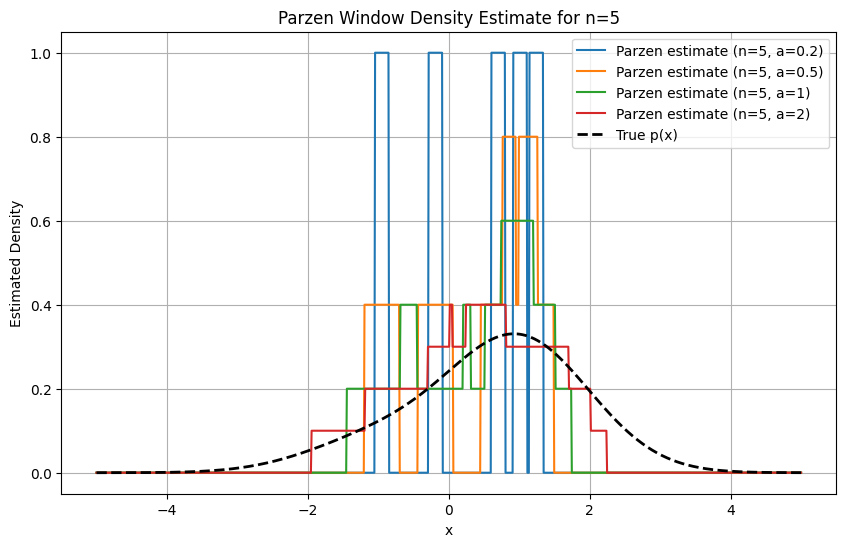

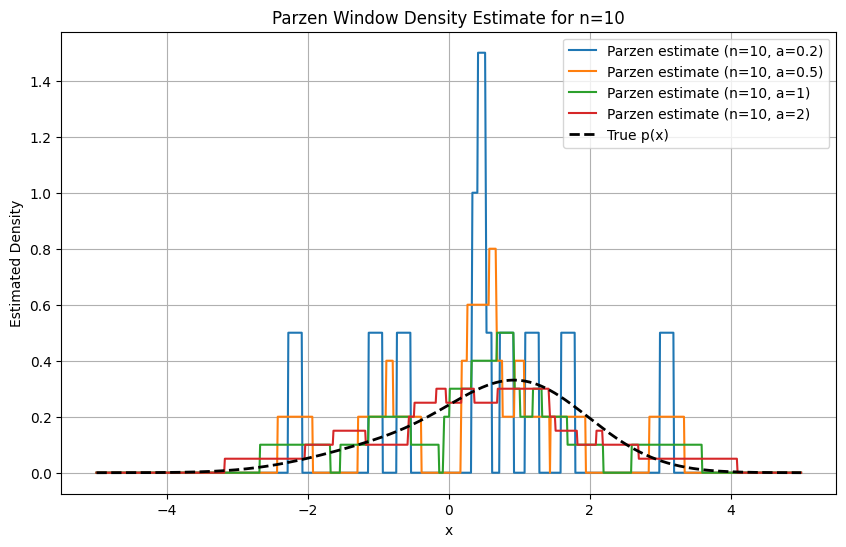

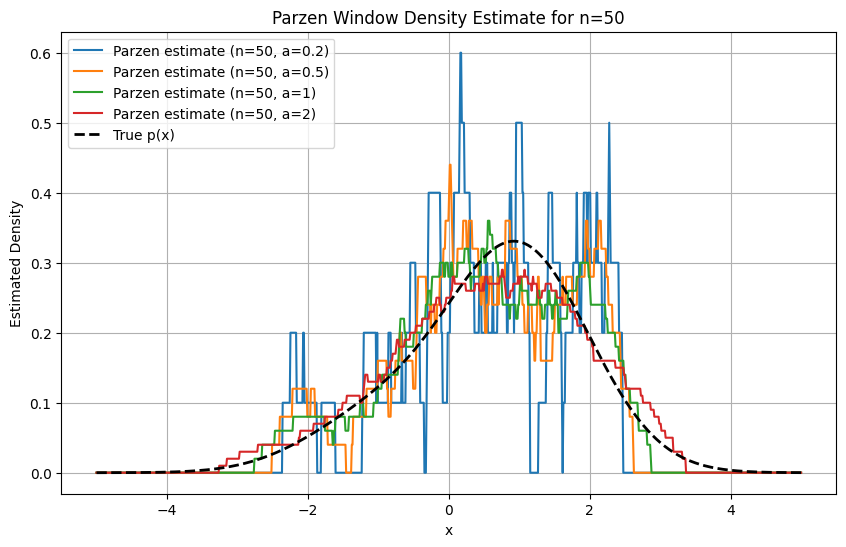

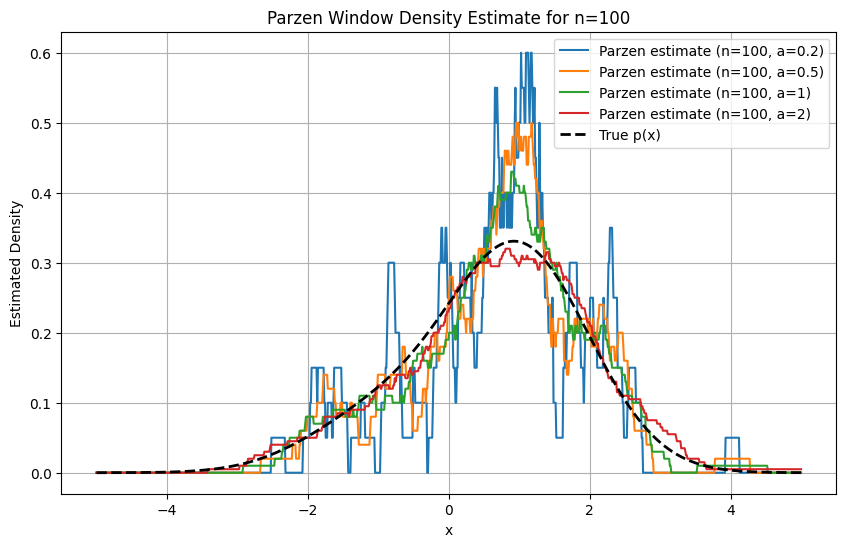

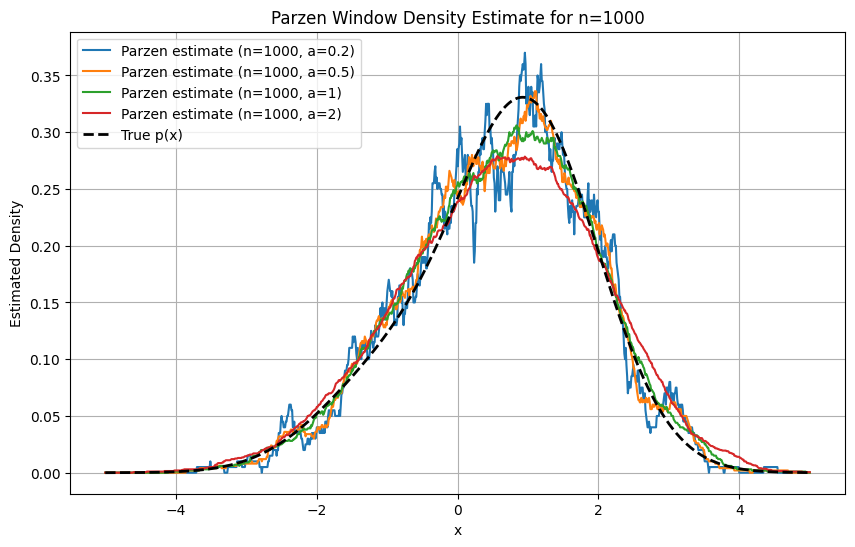

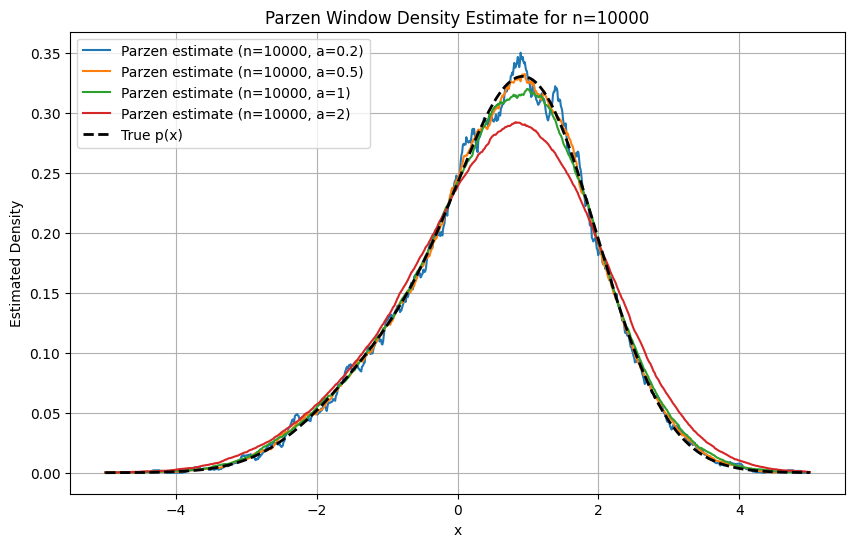

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def p_x(x):
    return 0.2 * norm.pdf(x, -1, 1) + 0.8 * norm.pdf(x, 1, 1)

def parzen_window(x, xi, a):
    return np.where(np.abs(x - xi) <= a / 2, 1 / a, 0)

def parzen_estimate(x, data, a):
    n = len(data)
    estimate = np.zeros_like(x)
    for xi in data:
        estimate += parzen_window(x, xi, a)
    return estimate / n

n_values = [5, 10, 50, 100, 1000, 10000]
a_values = [0.2, 0.5, 1, 2]

def generate_samples(n):
    samples = np.hstack([np.random.normal(-1, 1, int(0.2 * n)), np.random.normal(1, 1, int(0.8 * n))])
    return samples

x_values = np.linspace(-5, 5, 1000)
true_p = p_x(x_values)

for n in n_values:
    samples = generate_samples(n)
    plt.figure(figsize=(10, 6))
    for a in a_values:
        estimated_p = parzen_estimate(x_values, samples, a)
        plt.plot(x_values, estimated_p, label=f'Parzen estimate (n={n}, a={a})')
    plt.plot(x_values, true_p, 'k--', label='True p(x)', linewidth=2)
    plt.title(f'Parzen Window Density Estimate for n={n}')
    plt.xlabel('x')
    plt.ylabel('Estimated Density')
    plt.legend()
    plt.grid(True)
    plt.show()


In [3]:
def compute_error(n, a, x_values, true_p, num_trials=100):
    errors = []
    for _ in range(num_trials):
        samples = np.hstack([np.random.normal(-1, 1, int(0.2 * n)), np.random.normal(1, 1, int(0.8 * n))])
        estimated_p = parzen_estimate(x_values, samples, a)
        error = np.sum((estimated_p - true_p) ** 2 * dx)
        errors.append(error)
    return np.mean(errors), np.var(errors)

a_values = [0.2, 0.5, 1, 2]
n_values = [5, 10, 50, 100, 1000, 10000]
x_values = np.linspace(-5, 5, 1000)
dx = (x_values[1] - x_values[0])
true_p = p_x(x_values)

# 计算不同 a 和 n 下的期望误差和方差
for a in a_values:
    for n in n_values:
        mean_error, var_error = compute_error(n, a, x_values, true_p)
        print(f"a = {a}, n = {n}, Mean Error = {mean_error}, Variance = {var_error}")

a = 0.2, n = 5, Mean Error = 0.9286562610937611, Variance = 0.03334347088498877
a = 0.2, n = 10, Mean Error = 0.4824156385901713, Variance = 0.011898865256714138
a = 0.2, n = 50, Mean Error = 0.09727323028843121, Variance = 0.0007603991728038654
a = 0.2, n = 100, Mean Error = 0.04497579003543525, Variance = 9.708283557847622e-05
a = 0.2, n = 1000, Mean Error = 0.004692527877418355, Variance = 1.2353127059645049e-06
a = 0.2, n = 10000, Mean Error = 0.00047609113459440923, Variance = 9.444919468743204e-09
a = 0.5, n = 5, Mean Error = 0.35731735175358553, Variance = 0.015638871268799343
a = 0.5, n = 10, Mean Error = 0.1739177691668868, Variance = 0.0030737284066228087
a = 0.5, n = 50, Mean Error = 0.037105717015339615, Variance = 0.0002112274094017888
a = 0.5, n = 100, Mean Error = 0.017113997556487525, Variance = 4.016576114736689e-05
a = 0.5, n = 1000, Mean Error = 0.0018221744629346925, Variance = 4.4410802174454084e-07
a = 0.5, n = 10000, Mean Error = 0.00017405392975490053, Variance 

In [ ]:
def gaussian_parzen_window(x, xi, a):
    return (1 / (np.sqrt(2 * np.pi) * a)) * np.exp(-0.5 * ((x - xi) / a) ** 2)

def parzen_estimate(x, data, a):
    n = len(data)
    estimate = np.zeros_like(x)
    for xi in data:
        estimate += gaussian_parzen_window(x, xi, a)
    return estimate / n


x_values = np.linspace(-5, 5, 1000)
true_p = p_x(x_values)

for n in n_values:
    samples = generate_samples(n)
    plt.figure(figsize=(10, 6))
    for a in a_values:
        estimated_p = parzen_estimate(x_values, samples, a)
        plt.plot(x_values, estimated_p, label=f'Parzen estimate (n={n}, a={a})')
    plt.plot(x_values, true_p, 'k--', label='True p(x)', linewidth=2)
    plt.title(f'Parzen Window Density Estimate for n={n}')
    plt.xlabel('x')
    plt.ylabel('Estimated Density')
    plt.legend()
    plt.grid(True)
    plt.show()